# Netflix Movies and TV Shows — Exploratory Data Analysis (EDA)

### Objective
This project performs exploratory data analysis on the Netflix Movies and TV Shows dataset using Python, Pandas, and Matplotlib.

### Tools Used
- Python
- Pandas
- Matplotlib

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load and Understand the Dataset

We inspect the dataset dimensions, structure, data types, and basic statistics before cleaning.

In [2]:
df = pd.read_csv("netflix_titles.csv")
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [3]:
print(df.shape)

(8807, 12)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB
None


In [5]:
print(df.describe())

       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


## 2. Data Cleaning

In this section, we check and handle missing values, convert date columns to datetime format, fix data quality issues, and check for duplicate records.

In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [30]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")

In [31]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="mixed"
)

In [32]:
print("Dupliccate rows:", df.duplicated().sum())

Dupliccate rows: 0


In [33]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

## 3. Univariate Analysis

In this section, we analyze individual columns to understand the distribution of Movies, TV Shows, countries, genres, and ratings.

In [34]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [35]:
type_percentage = df['type'].value_counts(normalize=True)*100
print(type_percentage.round(2))

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64


In [36]:
countries = df["country"].str.split(",").explode()
countries = countries.str.strip()
countries = countries[countries != "unknown"]

print(countries.value_counts().head(10))

country
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64


In [37]:
genres = df["listed_in"].str.split(",").explode()
genres = genres.str.strip()
print(genres.value_counts().head(10))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [38]:
mask = df["rating"].isin(["74 min", "84 min", "66 min"])

df.loc[mask, "duration"] = df.loc[mask, "rating"]
df.loc[mask, "rating"] = "Unknown"
rating_counts = df["rating"].value_counts()

print(rating_counts)

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64


In [39]:
rating_by_type = (
    df.groupby(["rating", "type"])
      .size()
      .reset_index(name="count")
)

print(rating_by_type)

      rating     type  count
0          G    Movie     41
1      NC-17    Movie      3
2         NR    Movie     75
3         NR  TV Show      5
4         PG    Movie    287
5      PG-13    Movie    490
6          R    Movie    797
7          R  TV Show      2
8      TV-14    Movie   1427
9      TV-14  TV Show    733
10      TV-G    Movie    126
11      TV-G  TV Show     94
12     TV-MA    Movie   2062
13     TV-MA  TV Show   1145
14     TV-PG    Movie    540
15     TV-PG  TV Show    323
16      TV-Y    Movie    131
17      TV-Y  TV Show    176
18     TV-Y7    Movie    139
19     TV-Y7  TV Show    195
20  TV-Y7-FV    Movie      5
21  TV-Y7-FV  TV Show      1
22        UR    Movie      3
23   Unknown    Movie      5
24   Unknown  TV Show      2


In [40]:
rating_pivot = rating_by_type.pivot_table(
    index="rating",
    columns="type",
    values="count",
    fill_value=0
)

print(rating_pivot)

type       Movie  TV Show
rating                   
G           41.0      0.0
NC-17        3.0      0.0
NR          75.0      5.0
PG         287.0      0.0
PG-13      490.0      0.0
R          797.0      2.0
TV-14     1427.0    733.0
TV-G       126.0     94.0
TV-MA     2062.0   1145.0
TV-PG      540.0    323.0
TV-Y       131.0    176.0
TV-Y7      139.0    195.0
TV-Y7-FV     5.0      1.0
UR           3.0      0.0
Unknown      5.0      2.0


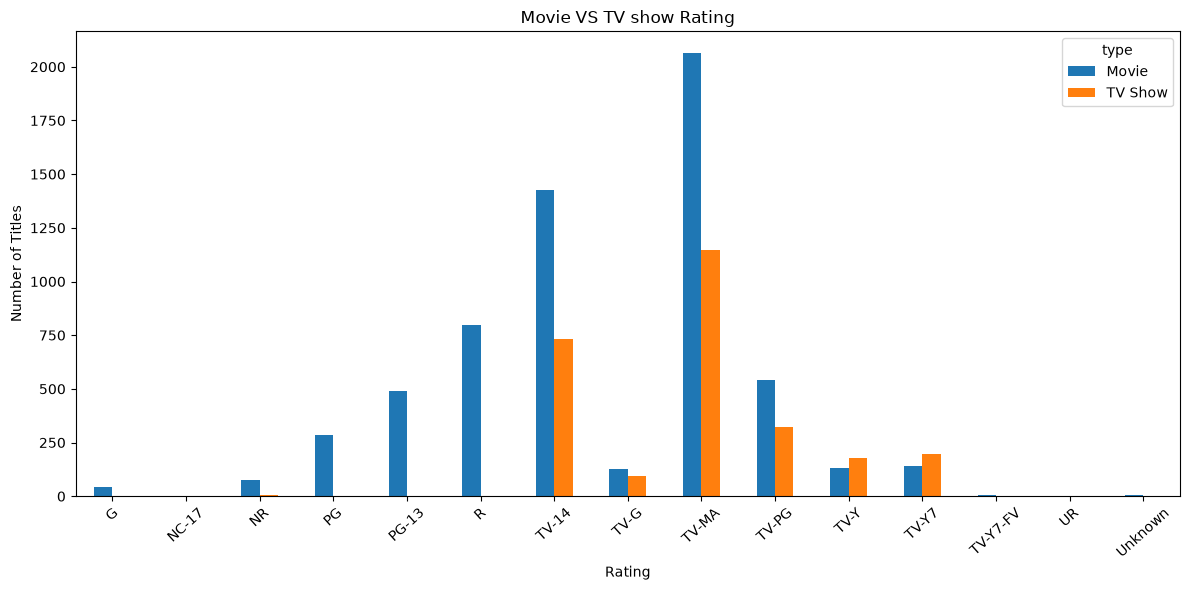

In [41]:
rating_pivot.plot(kind="bar",figsize=(12,6))
plt.title("Movie VS TV show Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=42)
plt.tight_layout()
plt.show()

## 4. Bivariate Analysis

In this section, we compare relationships between two variables, including Movies vs TV Shows by release year and country.

In [42]:
content_year = (
    df.groupby(['release_year','type'])
    .size()
    .reset_index(name='count')
)
print(content_year.tail(10))

     release_year     type  count
109          2017    Movie    767
110          2017  TV Show    265
111          2018    Movie    767
112          2018  TV Show    380
113          2019    Movie    633
114          2019  TV Show    397
115          2020    Movie    517
116          2020  TV Show    436
117          2021    Movie    277
118          2021  TV Show    315


In [20]:
content_pivot = content_year.pivot(
    index="release_year",
    columns="type",
    values="count"
)

print(content_pivot.tail())

type          Movie  TV Show
release_year                
2017          767.0    265.0
2018          767.0    380.0
2019          633.0    397.0
2020          517.0    436.0
2021          277.0    315.0


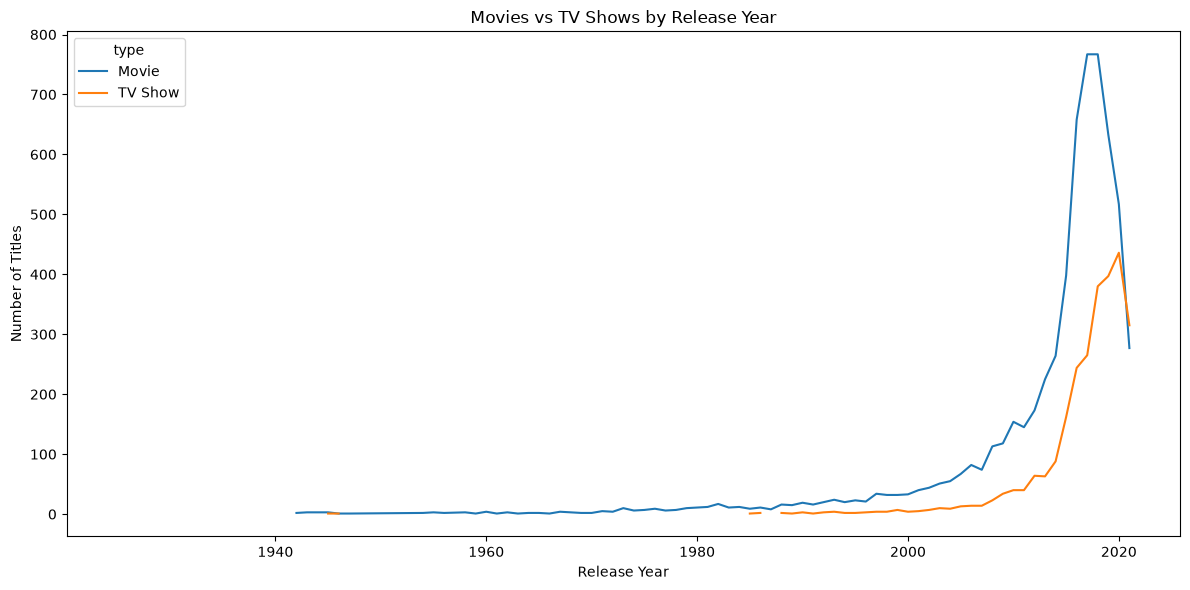

In [43]:
content_pivot.plot(kind="line", figsize=(12, 6))

plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()


In [44]:
country_type = df[["country", "type"]].copy()

country_type["country"] = country_type["country"].str.split(",")
country_type = country_type.explode("country")

country_type["country"] = country_type["country"].str.strip()

country_type_count = (
    country_type
    .groupby(["country", "type"])
    .size()
    .reset_index(name="count")
)

top_5_countries = [
    "United States",
    "United Kingdom",
    "India",
    "Canada",
    "France"
]

top_5 = country_type_count[
    country_type_count["country"].isin(top_5_countries)
]

print(top_5)

            country     type  count
27           Canada    Movie    319
28           Canada  TV Show    126
52           France    Movie    303
53           France  TV Show     90
67            India    Movie    962
68            India  TV Show     84
172  United Kingdom    Movie    534
173  United Kingdom  TV Show    272
174   United States    Movie   2752
175   United States  TV Show    938


In [23]:
top_5_pivot = top_5.pivot(
    index='country',
    columns='type',
    values='count'
)
print(top_5_pivot)

type            Movie  TV Show
country                       
Canada            319      126
France            303       90
India             962       84
United Kingdom    534      272
United States    2752      938


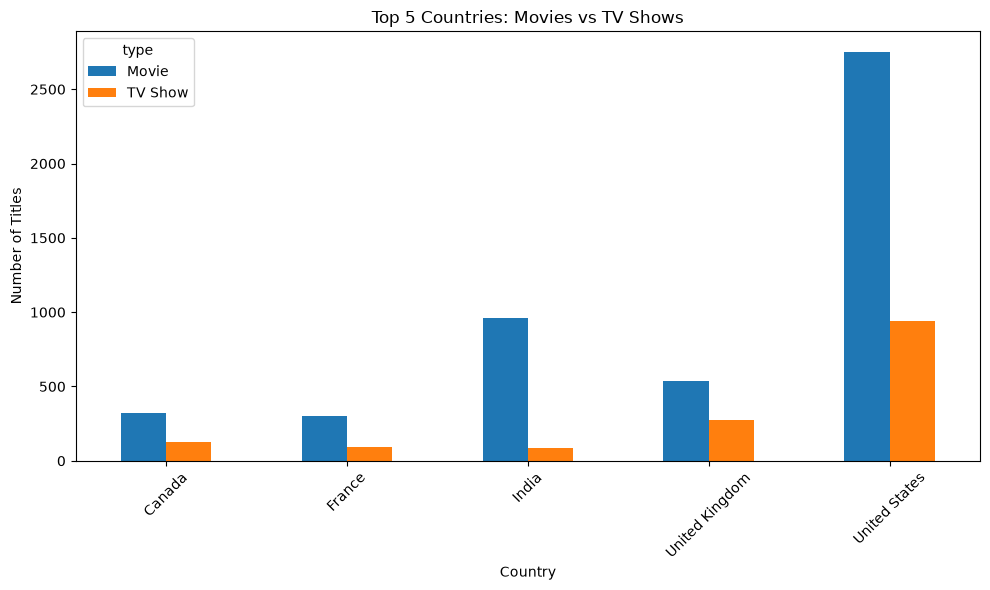

In [45]:
top_5_pivot.plot(kind="bar", figsize=(10, 6))

plt.title("Top 5 Countries: Movies vs TV Shows")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Key Performance Indicators (KPIs)

This section summarizes the most important metrics from the Netflix dataset.

In [8]:
total_titles = len(df)

total_movies = (df["type"] == "Movie").sum()

total_tv_shows = (df["type"] == "TV Show").sum()

movie_percentage = (total_movies / total_titles) * 100

tv_show_percentage = (total_tv_shows / total_titles) * 100

total_countries = df["country"].str.split(",").explode().str.strip().nunique()

print("Total Titles:", total_titles)
print("Total Movies:", total_movies)
print("Total TV Shows:", total_tv_shows)
print("Movie Share:", round(movie_percentage, 2), "%")
print("TV Show Share:", round(tv_show_percentage, 2), "%")
print("Total Countries:", total_countries)

Total Titles: 8807
Total Movies: 6131
Total TV Shows: 2676
Movie Share: 69.62 %
TV Show Share: 30.38 %
Total Countries: 123


## 6. Key Findings
Movies make up 69.62% of the titles in the dataset, while TV Shows make up 30.38%.

The United States is the country associated with the highest number of Netflix titles, followed by India and the United Kingdom.

International Movies, Dramas, and Comedies are the most common genres in the dataset.

TV-MA is the most common rating for both Movies and TV Shows.

Netflix content increased strongly in the later release years, with particularly high numbers during the 2010s and early 2020s.

In 2021, TV Shows (315) outnumbered Movies (277), unlike most of the preceding recent years.